In [1]:
import sys
import os

# Add the directory containing 'IsingRG.py' to sys.path.
# Based on the kernel state, this is likely '/content/drive/ColabNotebooks/IsingCG-main'.
ising_cg_path = '/content/drive/ColabNotebooks/IsingCG-main'
if ising_cg_path not in sys.path:
    sys.path.append(ising_cg_path)

# Verify the contents of the directory
print(f"Listing contents of {ising_cg_path}:")
!ls {ising_cg_path}

from IsingRG import *
import jax
import jax.numpy as jnp
import matplotlib.pylab as plt
import optax
from tqdm import tqdm
import seaborn as sns

Listing contents of /content/drive/ColabNotebooks/IsingCG-main:
ls: cannot access '/content/drive/ColabNotebooks/IsingCG-main': No such file or directory


In [2]:
#from google.colab import drive
#drive.mount('/content/drive/ColabNotebooks/IsingCG-main')

In [3]:
import inspect
print(inspect.signature(Sample))

(initial_configuration, rng, num_flips, num_samples, K, h, h3)


In [4]:
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = ['Times New Roman']

Definition of the random geneartor keys

In [5]:
rng_ = jax.random.PRNGKey(1)
rng_, rng_configuration, rng_sampling, rng_blocking, rng_batch = jax.random.split(rng_, 5)

# Simulation of the ising model

We extract and plot a random initial configuration

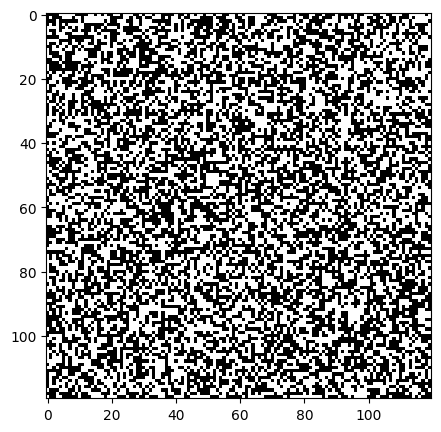

In [6]:
L = 120 #60 #128 #120
initial_configuration = jax.random.randint(rng_configuration, (L, L), minval=0, maxval=2) * 2 - 1
plt.rcParams["figure.figsize"] = (6,5)
fig, ax = plt.subplots(1,1)
ax.imshow(initial_configuration, cmap = 'gray')
plt.show()

### Sampling of the configuraitons

Using the function Sample() We can sample configurations from the Ising probability distribution
$$ \mathcal P = \frac 1 Z \exp \left( - \sum_{d}\sum_{|n-m| = d} \mathcal K_d \ \sigma_{n_x, n_y} \sigma_{m_x, m_y}  \right ) $$
with nearest neighbours interaction $\mathcal K_1 = 0.2$ and next nearest neighbours interaction $\mathcal K_2 = 0.08$.

We use a standard Metropolis Monte Carlo sampling algorithm

In [7]:
#K_simulation = jnp.array([0.203, 0.078])
K_simulation = jnp.array([0.18, 0.08]) #paramagnetica values of the parameters

num_samples = 300
num_filps = 10*L*L

h = 1e-4 # VALUE OF MAGNETIC FIELD
h3 = 0.0 # VALUE OF 3-SPIN OPERATOR

Samples = Sample(initial_configuration, rng_sampling, num_filps, num_samples, K_simulation, h, h3);

Let's show some of the generated configurations

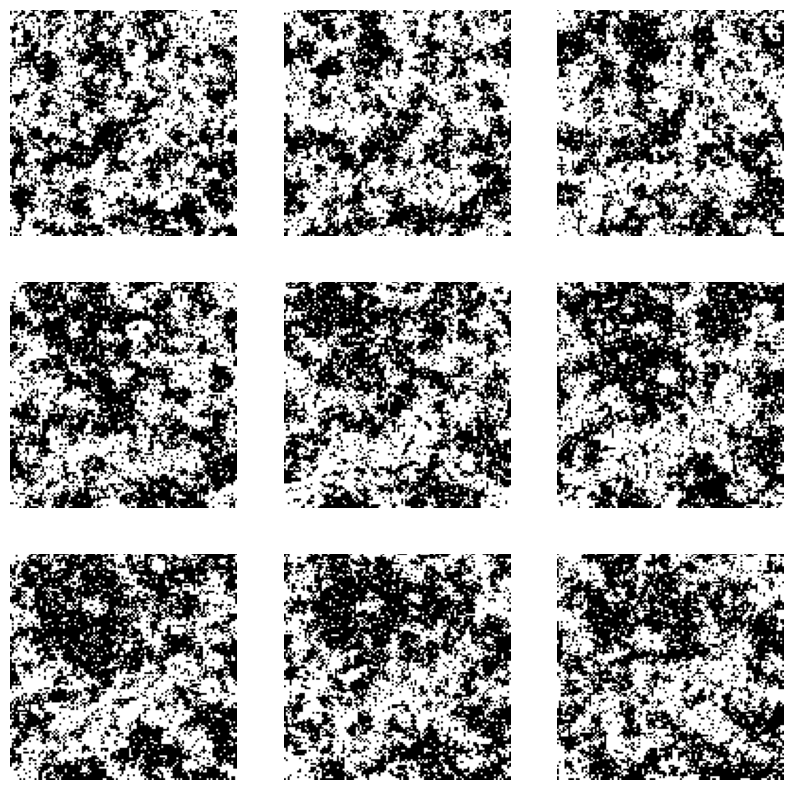

In [8]:
n = 3
m = 3
fig, ax = plt.subplots(n,m, figsize=(10,10))
for i in range (ax.size):
    x,y = divmod(i,m)
    ax[x,y].imshow(Samples[i,:,:], cmap='gray')
    ax[x,y].axis(False)

## Blocking

Let's see the effect of the blocking procedure on some configurations of the ising model:

In [9]:
rng_simulation1, rng_simulation2, rng_simulation3 = jax.random.split(rng_sampling, 3)
initial_configuration = jnp.ones((L,L))
K_paramagnetic = jnp.array([0.2])
K_ferromagnetic = jnp.array([0.48])
K_near_critical = jnp.array([0.4])

num_samples = 600
Samples_para = Sample(initial_configuration, rng_simulation1, L * L, num_samples, K_paramagnetic, h, h3)
Samples_ferro = Sample(initial_configuration, rng_simulation2, L * L, num_samples, K_ferromagnetic, h, h3)
Samples_near_critical = Sample(initial_configuration, rng_simulation3, L * L, num_samples, K_near_critical, h, h3)


Let's check that effectively as claimed the configurations are respectively in the paramagnetic, ferromagnetic and critical regime

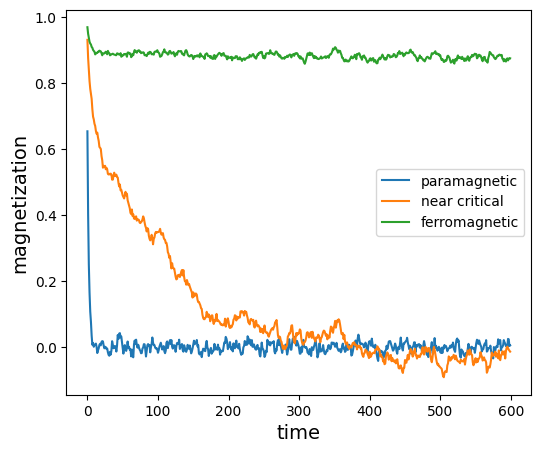

In [10]:
plt.plot(jnp.average(Samples_para, axis=[1,2]), label = "paramagnetic")
plt.plot(jnp.average(Samples_near_critical, axis=[1,2]), label = "near critical")
plt.plot(jnp.average(Samples_ferro, axis=[1,2]), label = "ferromagnetic")
plt.xlabel("time", fontsize=14)
plt.ylabel("magnetization", fontsize = 14)
plt.legend(fontsize=10)
plt.show()

Clearly the blue and green curves correspond respectively to the paramagnetic and ferromagnetic phases. We can tell that the orange curve corresponds to a near critical system because of its slow dynamics

### Blocking

Here we show the effect of the blocking  transformation on some configurations of the Ising model:

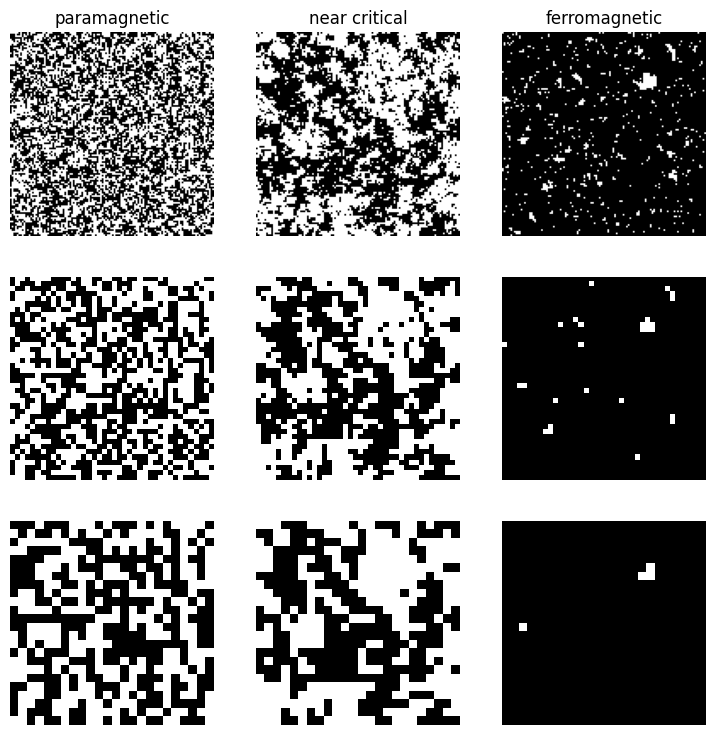

In [11]:
fig, ax = plt.subplots(3,3, figsize = (9,9));
ax[0,0].set_title("paramagnetic")
ax[0,1].set_title("near critical")
ax[0,2].set_title("ferromagnetic")

for i,x in enumerate([Samples_para, Samples_near_critical, Samples_ferro]):
    for j,bs in enumerate([1,3,5]):
        x_blocked =  Block_configuration(x[-1,:,:][jnp.newaxis,:,:], bs, rng_blocking)
        """The function Block configurations is made to work on a set of configurations of the type
        [num_samples,L,L], so if we want to apply this function to a single configuration we have to add a
        dummy axis with jnp.new-axis"""
        ax[j,i].imshow(-x_blocked[0,:,:], cmap='gray')
        ax[j,i].axis(False)

## Inference - Inverse Ising Problem

### Loss landscape

The solution of the inverse Ising problem is obtained by minimizing the function,

$$ F = \sum_{n} f_n $$

Which is implemented in function Pseudo_Loss in the IsingRG_lib.py file, see equation 20 in the main text

Before proceeding with the solution of the optimization problem we plot the function F on the $\{ \mathcal K_1, \ \mathcal K_2 \}$ plane

In [12]:
h, h3

(0.0001, 0.0)

In [13]:
termalization_steps = 100
batch = jax.random.permutation(rng_batch, num_samples-termalization_steps)[0:100]+termalization_steps
k1_grid, k2_grid = jnp.meshgrid(jnp.linspace(-0.1,0.5,20), jnp.linspace(-0.1,0.5,20));
k_grid = jnp.stack([k1_grid, k2_grid]).transpose(1,2,0)
loss_k1_k2 = (lambda x,y : Pseudo_Loss([x,y], h, h3, Samples[batch]))
landscape = jax.vmap(loss_k1_k2, in_axes=(0,0))(k1_grid.reshape(-1),k2_grid.reshape(-1)).reshape(k1_grid.shape);

k1h_grid, h_grid = jnp.meshgrid(jnp.linspace(-0.1,0.5,20), jnp.linspace(-0.5,0.5,20));
loss_k_h = (lambda x, y : Pseudo_Loss(jnp.array([x, 0.08]), y, h3, Samples[batch]))
landscape_kh = jax.vmap(loss_k_h, in_axes=(0,0))(k1h_grid.reshape(-1), h_grid.reshape(-1)).reshape(k1h_grid.shape)

k1h3_grid, h3_grid = jnp.meshgrid(jnp.linspace(-0.1,0.5,20), jnp.linspace(-0.5,0.5,20));
loss_k_h3 = (lambda x, y : Pseudo_Loss(jnp.array([x, 0.08]), h, y, Samples[batch]))
landscape_kh3 = jax.vmap(loss_k_h3, in_axes=(0,0))(k1h3_grid.reshape(-1), h3_grid.reshape(-1)).reshape(k1h3_grid.shape)


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2820/2584611751.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
/tmp/ipykernel_2820/2584611751.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathcal{K}_2$", fontsize = 18)


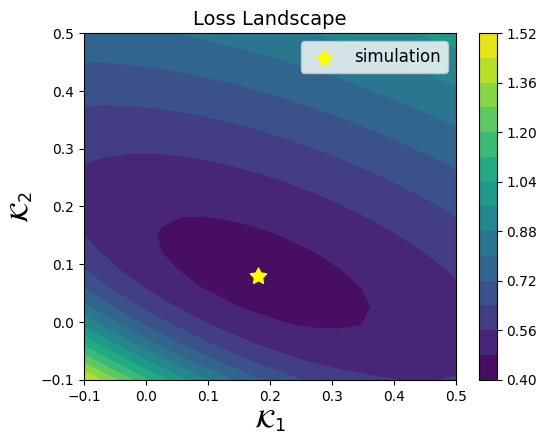

In [14]:
cmap =  sns.color_palette("viridis", as_cmap=True)
plt.rcParams["figure.figsize"] = (6,4.5)
plt.contourf(k1_grid, k2_grid, landscape, 15, cmap=cmap)
plt.colorbar()
plt.scatter([K_simulation[0]],[K_simulation[1]], c="yellow", marker=(5,1), s=150, label = "simulation")
plt.legend(fontsize = 12)
plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
plt.ylabel("$\mathcal{K}_2$", fontsize = 18)
plt.title("Loss Landscape", fontsize = 14)
plt.show()

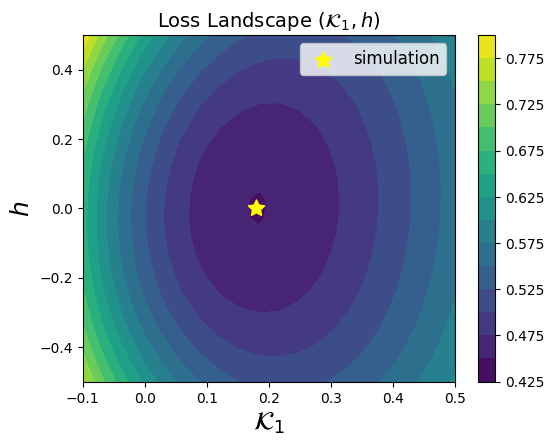

In [15]:
cmap = sns.color_palette("viridis", as_cmap=True)
plt.rcParams["figure.figsize"] = (6,4.5)
plt.contourf(k1h_grid, h_grid, landscape_kh, 15, cmap=cmap)
plt.colorbar()
plt.scatter([K_simulation[0]], h, c="yellow", marker=(5,1), s=150, label="simulation")
plt.legend(fontsize=12)
plt.xlabel("$\\mathcal{K}_1$", fontsize=18)
plt.ylabel("$h$", fontsize=18)

#plt.ylim(-0.1,0.1)

plt.title("Loss Landscape $(\\mathcal{K}_1, h)$", fontsize=14)
plt.show()

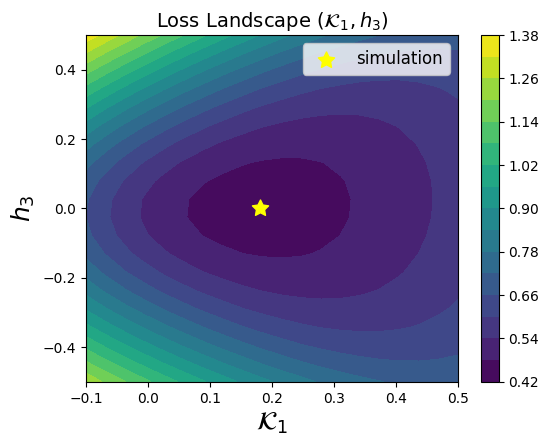

In [16]:
cmap = sns.color_palette("viridis", as_cmap=True)
plt.rcParams["figure.figsize"] = (6,4.5)
plt.contourf(k1h3_grid, h3_grid, landscape_kh3, 15, cmap=cmap)
plt.colorbar()
plt.scatter([K_simulation[0]], h3, c="yellow", marker=(5,1), s=150, label="simulation")
plt.legend(fontsize=12)
plt.xlabel("$\\mathcal{K}_1$", fontsize=18)
plt.ylabel("$h_3$", fontsize=18)

#plt.ylim(-0.1,0.1)

plt.title("Loss Landscape $(\\mathcal{K}_1, h_3)$", fontsize=14)
plt.show()

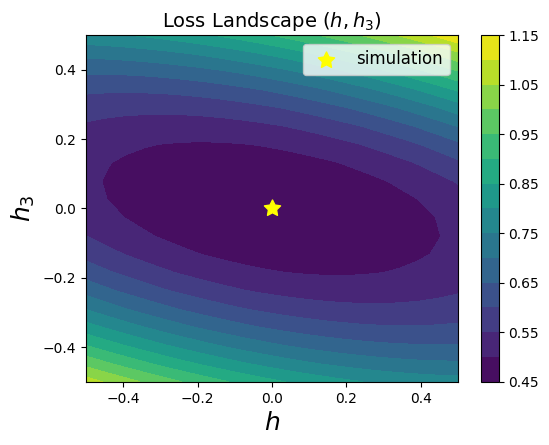

In [17]:
h_h3_grid_h, h_h3_grid_h3 = jnp.meshgrid(jnp.linspace(-0.5,0.5,20), jnp.linspace(-0.5,0.5,20));
loss_h_h3 = (lambda x, y : Pseudo_Loss(jnp.array([0.18, 0.08]), x, y, Samples[batch]))
landscape_h_h3 = jax.vmap(loss_h_h3, in_axes=(0,0))(h_h3_grid_h.reshape(-1), h_h3_grid_h3.reshape(-1)).reshape(h_h3_grid_h.shape)

cmap = sns.color_palette("viridis", as_cmap=True)
plt.rcParams["figure.figsize"] = (6,4.5)
plt.contourf(h_h3_grid_h, h_h3_grid_h3, landscape_h_h3, 15, cmap=cmap)
plt.colorbar()
plt.scatter(h, h3, c="yellow", marker=(5,1), s=150, label="simulation")
plt.legend(fontsize=12)
plt.xlabel("$h$", fontsize=18)
plt.ylabel("$h_3$", fontsize=18)
plt.title("Loss Landscape $(h, h_3)$", fontsize=14)
plt.show()

The yellow star corresponds to the parameters used to perform the simulation. We can see that the minimum of the loss function $F$ is very close to the parameters used to perform the simulation

### Inference

Let's see how the inference scheme proposed in the main text is able to find the minimum of the loss and infer the parameters of the model:

In [18]:
K_init = jnp.array([0.1,0.4])
K = K_init.copy()
K_trajectory_GD =[]

h_init = jnp.array(0.0005) # VALUE OF MAGNETIC FIELD INITIALIZATION
h = h_init.copy()
h_trajectory_GD =[]

h3_init = 0.0005 # VALUE OF 3-SPIN OPERATOR INITIALIZATION
h3 = h3_init
h3_trajectory_GD = []

Loss_trajectory_GD = []
eta = 0.07 # ETA, DELTA, STEP original 0.05


The function Pseudo_Loss_fn_and_grad in the Ising_RG.py file returns the loss and its gradient with respect to the couplings K, according to equation 21 of the main text. We optimize this function using the

In [19]:
for iterations in tqdm(range(300)):
    loss, grad_K, grad_h, grad_h3 = Pseudo_Loss_fn_and_grad(K, Samples[batch,:,:], h, h3)
    K_trajectory_GD.append(K)
    h_trajectory_GD.append(h)
    h3_trajectory_GD.append(h3)
    Loss_trajectory_GD.append(loss)
    K = K - eta*grad_K
    h = h - eta * grad_h
    h3 = h3 - eta * grad_h3


100%|██████████| 300/300 [00:04<00:00, 66.58it/s] 


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2820/4193916251.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
/tmp/ipykernel_2820/4193916251.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathcal{K}_2$", fontsize = 18)


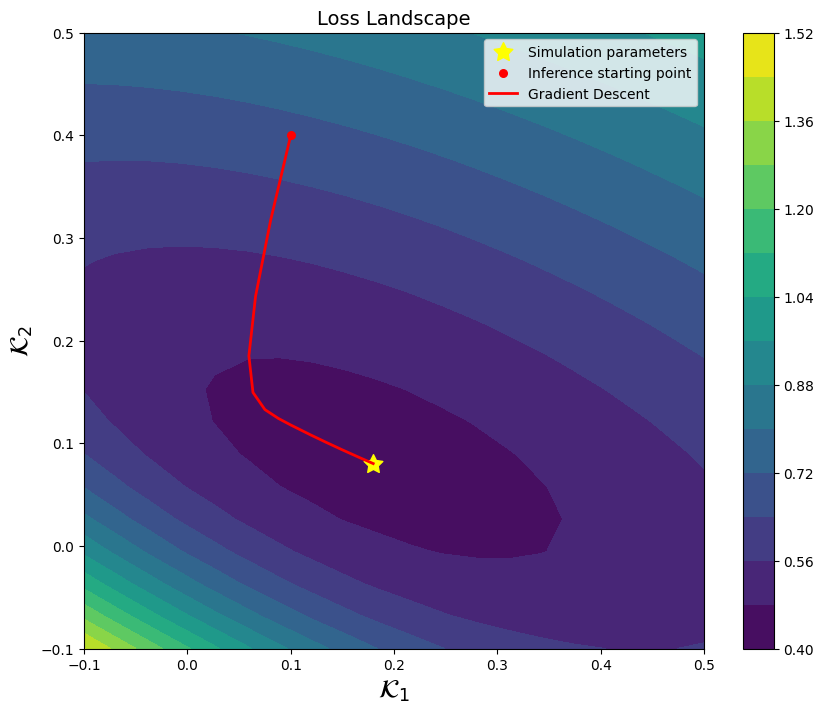

In [20]:
cmap =  sns.color_palette("viridis", as_cmap=True)
plt.rcParams["figure.figsize"] = (10,8)
Kt_GD = jnp.stack(K_trajectory_GD)
plt.contourf(k1_grid, k2_grid, landscape, 15, cmap=cmap)
plt.colorbar()
plt.scatter([K_simulation[0]],[K_simulation[1]], c="yellow", marker=(5,1), s=200, label = "Simulation parameters")
plt.scatter([K_init[0]],[K_init[1]], c="red", marker="o", s=30, label = "Inference starting point")
plt.legend(fontsize = 12)
plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
plt.ylabel("$\mathcal{K}_2$", fontsize = 18)
plt.title("Loss Landscape", fontsize = 14)
plt.plot(Kt_GD[:,0], Kt_GD[:,1], c='red', lw = 2, label = "Gradient Descent")
plt.legend(fontsize = 10)
# plt.savefig("optimization_trajectory.pdf")
plt.show()

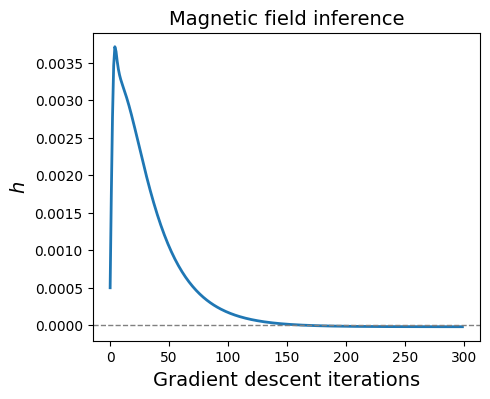

In [21]:
plt.rcParams["figure.figsize"] = (5,4)
plt.plot(h_trajectory_GD, lw=2)
plt.xlabel("Gradient descent iterations", fontsize=14)
plt.ylabel("$h$", fontsize=14)
plt.title("Magnetic field inference", fontsize=14)
plt.axhline(y=0, color='gray', linestyle='--', lw=1)

plt.show()

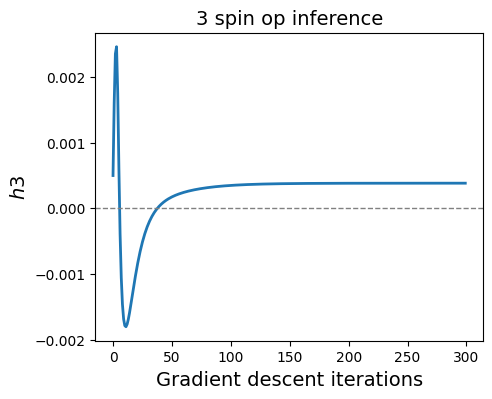

In [22]:
plt.rcParams["figure.figsize"] = (5,4)
plt.plot(h3_trajectory_GD, lw=2)
plt.xlabel("Gradient descent iterations", fontsize=14)
plt.ylabel("$h3$", fontsize=14)
plt.title("3 spin op inference", fontsize=14)
plt.axhline(y=0, color='gray', linestyle='--', lw=1)

#plt.xlim(-5,50)

plt.show()

In [23]:
h

Array(-1.9048688e-05, dtype=float32)

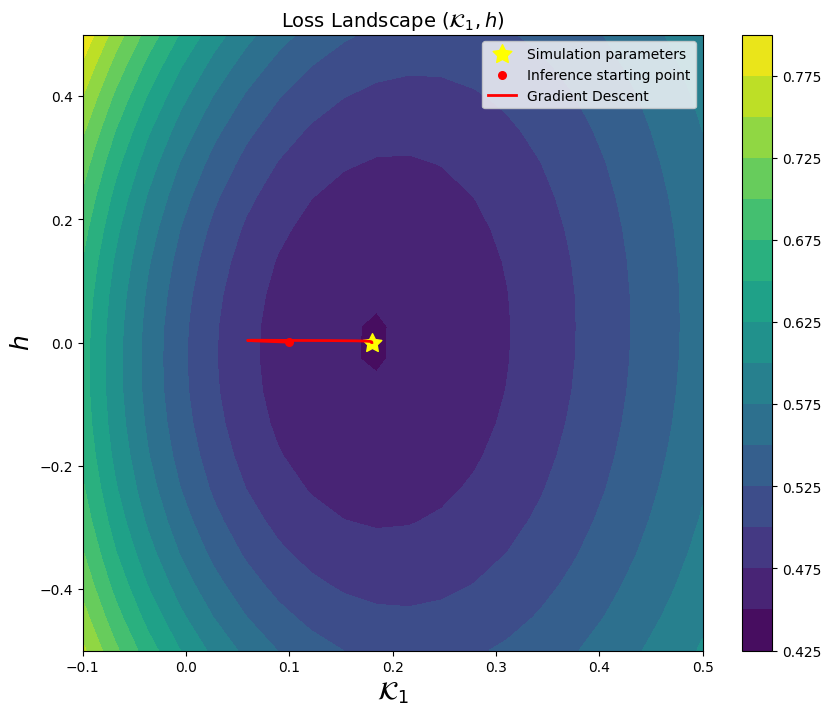

In [24]:
cmap = sns.color_palette("viridis", as_cmap=True)
plt.rcParams["figure.figsize"] = (10,8)
Kt_GD = jnp.stack(K_trajectory_GD)
plt.contourf(k1h_grid, h_grid, landscape_kh, 15, cmap=cmap)
plt.colorbar()
plt.scatter([K_simulation[0]], h, c="yellow", marker=(5,1), s=200, label="Simulation parameters")
plt.scatter([K_init[0]], h_init, c="red", marker="o", s=30, label="Inference starting point")
plt.xlabel("$\\mathcal{K}_1$", fontsize=18)
plt.ylabel("$h$", fontsize=18)
plt.title("Loss Landscape $(\\mathcal{K}_1, h)$", fontsize=14)
plt.plot(Kt_GD[:,0], h_trajectory_GD, c='red', lw=2, label="Gradient Descent")
plt.legend(fontsize=10)
plt.show()

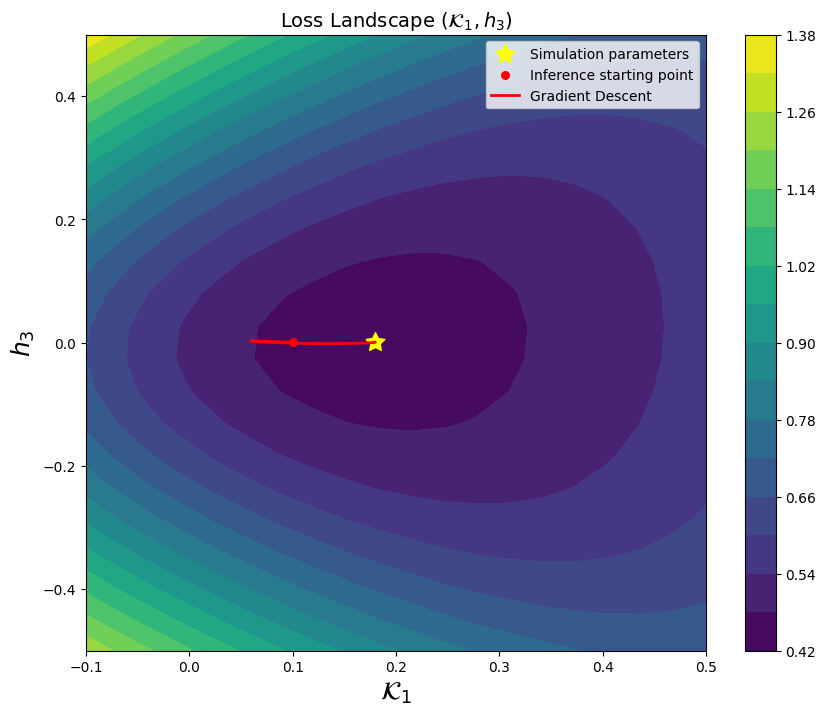

In [25]:
cmap = sns.color_palette("viridis", as_cmap=True)
plt.rcParams["figure.figsize"] = (10,8)
Kt_GD = jnp.stack(K_trajectory_GD)
plt.contourf(k1h3_grid, h3_grid, landscape_kh3, 15, cmap=cmap)
plt.colorbar()
plt.scatter([K_simulation[0]], h3, c="yellow", marker=(5,1), s=200, label="Simulation parameters")
plt.scatter([K_init[0]], h3_init, c="red", marker="o", s=30, label="Inference starting point")
plt.xlabel("$\\mathcal{K}_1$", fontsize=18)
plt.ylabel("$h_3$", fontsize=18)
plt.title("Loss Landscape $(\\mathcal{K}_1, h_3)$", fontsize=14)
plt.plot(Kt_GD[:,0], h3_trajectory_GD, c='red', lw=2, label="Gradient Descent")
plt.legend(fontsize=10)
plt.show()

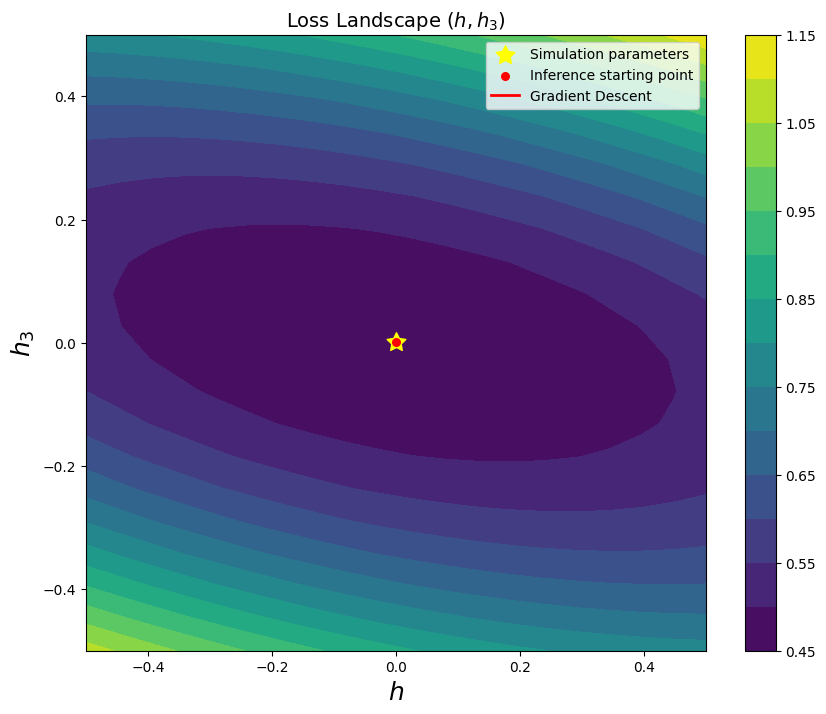

In [26]:
cmap = sns.color_palette("viridis", as_cmap=True)
plt.rcParams["figure.figsize"] = (10,8)
plt.contourf(h_h3_grid_h, h_h3_grid_h3, landscape_h_h3, 15, cmap=cmap)
plt.colorbar()
plt.scatter(h, h3, c="yellow", marker=(5,1), s=200, label="Simulation parameters")
plt.scatter(h_init, h3_init, c="red", marker="o", s=30, label="Inference starting point")
plt.xlabel("$h$", fontsize=18)
plt.ylabel("$h_3$", fontsize=18)

#plt.xlim(-0.1,0.1)
#plt.ylim(-0.1,0.1)

plt.title("Loss Landscape $(h, h_3)$", fontsize=14)
plt.plot(h_trajectory_GD, h3_trajectory_GD, c='red', lw=2, label="Gradient Descent")
plt.legend(fontsize=10)
plt.show()

### Adam Optimization (optional)

Instead of simply following the gradient we can try to use some more sophisticated optimization scheme. We use the Adam algorithm build in the optax package

In [27]:
K = jnp.array([0.1,0.4])
h = 0.01 # VALUE OF MAGNETIC FIELD initial
h3 = 0.0 # VALUE OF 3-SPIN OPERATOR initial
K_trajectory_ADAM = []
h_trajectory_ADAM = []
h3_trajectory_ADAM = []
Loss_trajectory_ADAM = []
eta = 0.05


In [28]:
optimizer = optax.adam(eta)
params = {'K': K}
opt_state = optimizer.init(params)
for iterations in tqdm(range(300)):
    loss, grads_K, grads_h, grads_h3 = Pseudo_Loss_fn_and_grad(params['K'], Samples[batch,:,:], h, h3)
    K_trajectory_ADAM.append(params['K'])
    h_trajectory_ADAM.append(h)
    h3_trajectory_ADAM.append(h3)
    Loss_trajectory_ADAM.append(loss)
    grads_K = {'K': grads_K}
    updates, opt_state = optimizer.update(grads_K, opt_state)
    params = optax.apply_updates(params, updates)
    h = h - eta * grads_h
    h3 = h3 - eta * grads_h3


100%|██████████| 300/300 [00:03<00:00, 84.15it/s] 


If we compare the solution of the gradient descent algorithm (basically following the gradient) with the Adam algorithm we see how faster ADAM finds the solution

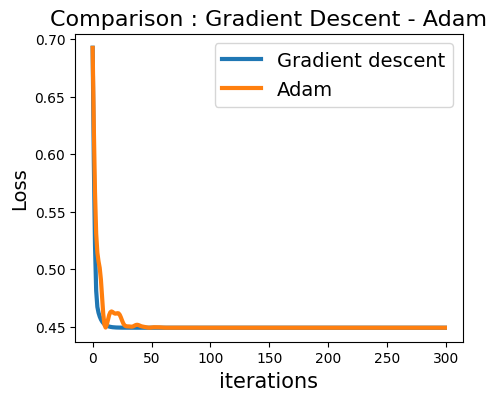

In [29]:
plt.rcParams["figure.figsize"] = (5,4)
plt.title("Comparison : Gradient Descent - Adam", fontsize=16)
plt.plot(Loss_trajectory_GD, lw = 3, label = "Gradient descent")
plt.plot(Loss_trajectory_ADAM, lw = 3, label = "Adam")
plt.xlabel("iterations", fontsize = 15)
plt.ylabel("Loss", fontsize = 14)
plt.legend(fontsize = 14)
plt.show()

We can clearly see how faster the Adam algorithm can find the solution.

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2820/3943990412.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
/tmp/ipykernel_2820/3943990412.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathcal{K}_2$", fontsize = 18)


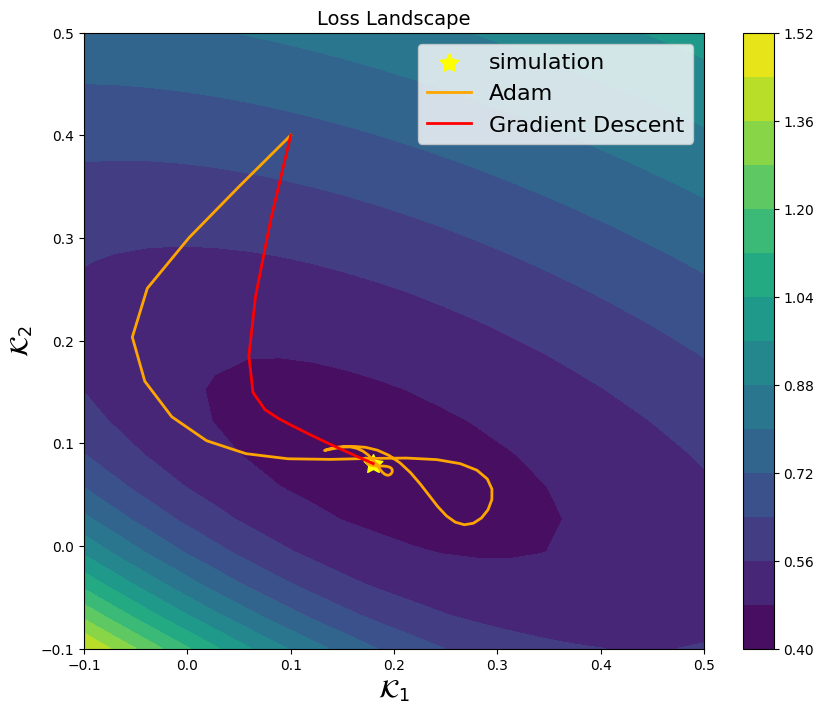

In [30]:
plt.rcParams["figure.figsize"] = (10,8)

Kt_ADAM = jnp.stack(K_trajectory_ADAM)
Kt_GD = jnp.stack(K_trajectory_GD)
plt.contourf(k1_grid, k2_grid, landscape, 15, cmap=cmap)
plt.colorbar()
plt.scatter([K_simulation[0]],[K_simulation[1]], c="yellow", marker=(5,1), s=200, label = "simulation")
plt.legend(fontsize = 12)
plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
plt.ylabel("$\mathcal{K}_2$", fontsize = 18)
plt.title("Loss Landscape", fontsize = 14)
plt.plot(Kt_ADAM[:,0], Kt_ADAM[:,1], c='orange', lw = 2, label = "Adam")
plt.plot(Kt_GD[:,0], Kt_GD[:,1], c='red', lw = 2, label = "Gradient Descent")
plt.legend(fontsize = 16)
plt.show()

Including the magnetic field

## Measuring the renormalization group flow

We are going to measure the renormalization group flow following the procedure described in figure 7 of the main text

#### single block size

First we are going to apply the procedure for a single block size.

The first step of the procedure described in figure 7 is to simulate the Ising model and get some equilibrium configurations:

In [31]:
h

Array(-1.19974675e-05, dtype=float32)

In [32]:
K_simulation = jnp.array([0.203, 0.078])
h_simulation = 1e-4 # VALUE OF MAGNETIC FIELD
h3_simulation = 0.0 # VALUE OF 3-SPIN OPERATOR

L = 240 #120 #240
initial_configuration = jnp.ones((L,L))
#num_samples = 6000 #3000 used in github
num_samples = 300
"""This might take a while"""
Samples = Sample(initial_configuration, rng_sampling, 30*L*L, num_samples, K_simulation, h_simulation, h3_simulation);

We plot the magnetization of the system over time to have any idea of what the system is doing

Text(0, 0.5, 'm')

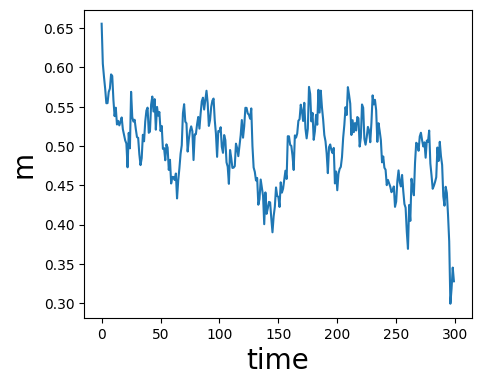

In [33]:
plt.rcParams["figure.figsize"] = (5,4)
plt.plot(jnp.average(Samples, axis =[1,2]))
plt.xlabel("time", fontsize =20)
plt.ylabel("m", fontsize =20)

We select some random configurations from Samples (neglecting the first half of the simulations, mainly because we want to use thermalized configurations and the first part of the dynamics is still influence by the initial condition)

Then we block the configurations using the BlockConfiguration function

In [34]:
termalization_steps = 100
batch_size = 1000
batch = jax.random.permutation(rng_,num_samples- termalization_steps )[0:batch_size] + termalization_steps
Block_size = 8
Blocked_Samples = Block_configuration(Samples[batch,:,:], Block_size,rng_blocking)

At this point we can apply the inverse Ising procedure to infer the couplings that would have generated the blocked configurations.

In [35]:
# eta = 1
K_initial = jnp.array([0.4, 0.4, 0.4, 0.4])
K = K_initial.copy()
K_trajectory = []

h = 1e-4 # VALUE OF MAGNETIC FIELD initialization
h_trajectory = []

h3 = 0.0 # VALUE OF 3-SPIN OPERATOR initialization
h3_trajectory = []

Loss_trajectory = []
eta = 0.025 # ETA, DELTA, STEP
for iterations in tqdm(range(75000)):
    loss, grad_K, grad_h, grad_h3 = Pseudo_Loss_fn_and_grad(K, Blocked_Samples, h, h3)
    K_trajectory.append(K)
    h_trajectory.append(h)
    h3_trajectory.append(h3)

    Loss_trajectory.append(loss)

    K = K - eta*grad_K
    h = h - eta * grad_h
    h3 = h3 - eta * grad_h3

K_blocked_traj_GD_np = jnp.stack(K_trajectory)


100%|██████████| 75000/75000 [01:42<00:00, 732.62it/s]


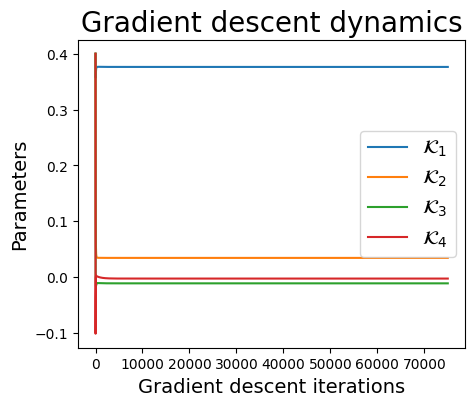

In [36]:
plt.rcParams["figure.figsize"] = (5,4)
plt.figure()
for i in range(4):
    plt.plot(K_blocked_traj_GD_np[:,i], label = "$\\mathcal{K}_"+str(i+1)+" $")
plt.legend(fontsize = 14)
plt.title("Gradient descent dynamics", fontsize = 20)
plt.xlabel("Gradient descent iterations", fontsize=14)
plt.ylabel("Parameters", fontsize=14)

#plt.xlim(5000,6000)

#plt.xscale("log")
plt.show()

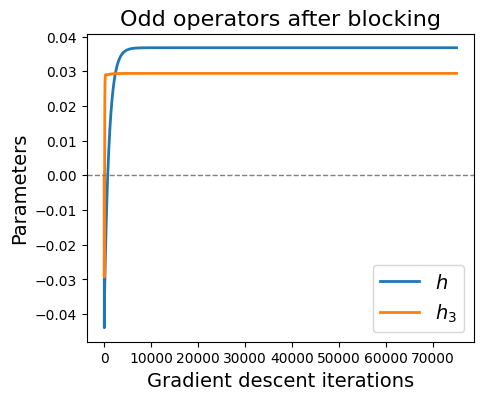

In [37]:
plt.rcParams["figure.figsize"] = (5,4)
plt.plot(h_trajectory, label="$h$", lw=2)
plt.plot(h3_trajectory, label="$h_3$", lw=2)
plt.axhline(y=0, color='gray', linestyle='--', lw=1)
plt.legend(fontsize=14)
plt.title("Odd operators after blocking", fontsize=16)
plt.xlabel("Gradient descent iterations", fontsize=14)
plt.ylabel("Parameters", fontsize=14)

#plt.xscale("log")

plt.show()

In [38]:
print(jnp.average(Blocked_Samples))

0.72444445


In [39]:
for b in [2, 3, 4, 5, 6, 8]:
    BS = Block_configuration(Samples[batch,:,:], b, rng_blocking)
    print(f"b = {b}: avg magnetization = {jnp.average(BS):.4f}")

b = 2: avg magnetization = 0.5587
b = 3: avg magnetization = 0.6209
b = 4: avg magnetization = 0.6498
b = 5: avg magnetization = 0.6744
b = 6: avg magnetization = 0.6935
b = 8: avg magnetization = 0.7244


#### Many block sizes and RG flow

The only step left is to loop over many block sizes and see how the inferred parameters change with the block size.

In [40]:
"""This might take a while"""
K_RG = []
h_RG = []
h3_RG = []
Block_sizes = [2,3,4,5,6,8]

for Block_size in Block_sizes:
    Blocked_Samples = Block_configuration(Samples[batch,:,:], Block_size, rng_blocking)
    K_initial = jnp.array([0., 0., 0.0, 0.0])
    K = K_initial.copy()
    h = 1e-4 # reset h for each block size VALUE MAGNETIC FIELD
    h3 = 0.0 # reset h3 for each block size
    K_trajectory = []
    h_trajectory = []
    h3_trajectory = []
    Loss_trajectory = []
    eta = 0.025
    for iterations in tqdm(range(7000)):
        loss, grad_K, grad_h, grad_h3 = Pseudo_Loss_fn_and_grad(K, Blocked_Samples, h, h3)
        K_trajectory.append(K)
        h_trajectory.append(h)
        h3_trajectory.append(h3)
        Loss_trajectory.append(loss)
        K = K - eta*grad_K
        h = h - eta * grad_h
        h3 = h3 - eta * grad_h3
    K_blocked_traj_GD_np = jnp.stack(K_trajectory)
    h_blocked_traj_GD_np = jnp.stack(h_trajectory)
    h3_blocked_traj_GD_np = jnp.stack(h3_trajectory)
    K_RG.append({'b': Block_size, 'K_traj': K_blocked_traj_GD_np.copy(), 'K': K_blocked_traj_GD_np[-1,:].copy()})
    h_RG.append({'b': Block_size, 'h_traj': h_blocked_traj_GD_np.copy(), 'h': h_blocked_traj_GD_np[-1].copy()})
    h3_RG.append({'b': Block_size, 'h3_traj': h3_blocked_traj_GD_np.copy(), 'h3': h3_blocked_traj_GD_np[-1].copy()})

100%|██████████| 7000/7000 [00:08<00:00, 781.27it/s]


In [41]:
K0 = [jnp.array([K_simulation[0],K_simulation[1],0,0])]
for k in K_RG:
    K0.append(k['K'])
Ks = jnp.stack(K0)

In [42]:
h_initial_simulation = jnp.array(0)

h0 = [h_initial_simulation]
for h_dict_item in h_RG:
    h0.append(h_dict_item['h'])
hs = jnp.stack(h0)

h3_initial_simulation = jnp.array(0)
h30 = [h3_initial_simulation]
for h3_dict_item in h3_RG:
    h30.append(h3_dict_item['h3'])
h3s = jnp.stack(h30)


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2820/1317472281.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
/tmp/ipykernel_2820/1317472281.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathcal{K}_2$", fontsize = 18)


[]

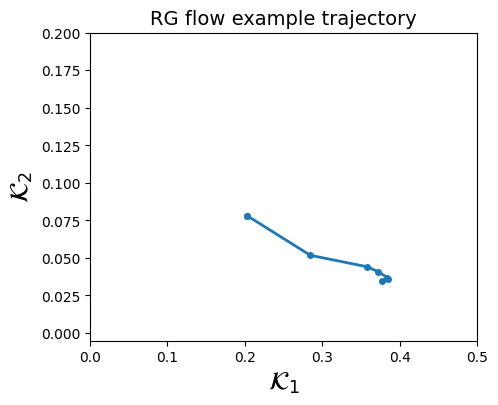

In [43]:
plt.rcParams["figure.figsize"] = (5,4);
K1_traj = list(Ks[:,0].copy())
K2_traj = list(Ks[:,1].copy())
K1_traj.insert(0,K_simulation[0])
K2_traj.insert(0,K_simulation[1])
plt.plot(K1_traj, K2_traj, marker="o", markersize=4, lw = 2)
plt.xlim(0,0.5)
plt.ylim(-0.005,0.2)
plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
plt.ylabel("$\mathcal{K}_2$", fontsize = 18)
plt.title("RG flow example trajectory", fontsize = 14)
plt.plot()

Figures 8 and 9 of the main text are obtained by iterating this procedure for different couplings

In [44]:
print(Ks[-1])

[ 0.37634626  0.03435387 -0.01119933 -0.00264614]


In [45]:
print(Ks)

[[ 0.203       0.078       0.          0.        ]
 [ 0.2842332   0.05174018  0.0012109  -0.00150299]
 [ 0.35776463  0.04407664 -0.00797453 -0.00167253]
 [ 0.37156826  0.04086534 -0.0106669  -0.00076072]
 [ 0.3838329   0.03687287 -0.01604456  0.00252563]
 [ 0.38462406  0.0356684  -0.01622383  0.00288109]
 [ 0.37634626  0.03435387 -0.01119933 -0.00264614]]


In [46]:
print(hs[-1])

0.03674445


In [47]:
print(hs)

[ 0.          0.00030614 -0.00094661  0.00201198  0.00213585  0.00562041
  0.03674445]


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2820/2563384824.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
/tmp/ipykernel_2820/2563384824.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathcal{h}$", fontsize = 18)


[]

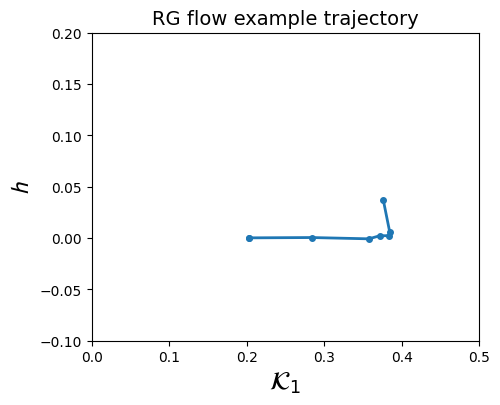

In [48]:
plt.rcParams["figure.figsize"] = (5,4);
#K1_traj = list(Ks[:,0].copy())
h_traj = list(hs.copy())
#K1_traj.insert(0,K_simulation[0])
h_traj.insert(0,h_simulation)
plt.plot(K1_traj, h_traj, marker="o", markersize=4, lw = 2)
plt.xlim(0,0.5)
plt.ylim(-0.1,0.2)
plt.xlabel("$\mathcal{K}_1$", fontsize = 18)
plt.ylabel("$\mathcal{h}$", fontsize = 18)
plt.title("RG flow example trajectory", fontsize = 14)
plt.plot()

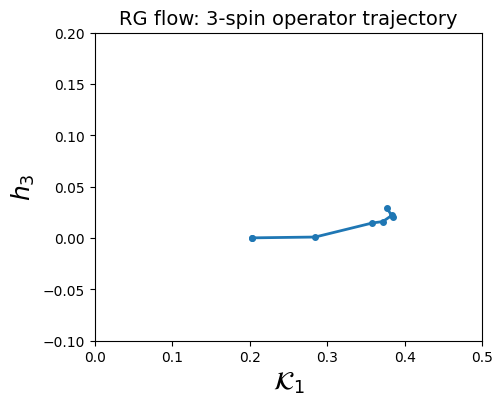

In [49]:
plt.rcParams["figure.figsize"] = (5,4);
h3_traj = list(h3s.copy())
h3_traj.insert(0, h3_simulation)
plt.plot(K1_traj, h3_traj, marker="o", markersize=4, lw=2)
plt.xlim(0, 0.5)
plt.ylim(-0.1, 0.2)
plt.xlabel("$\\mathcal{K}_1$", fontsize=18)
plt.ylabel("$h_3$", fontsize=18)
plt.title("RG flow: 3-spin operator trajectory", fontsize=14)
plt.show()

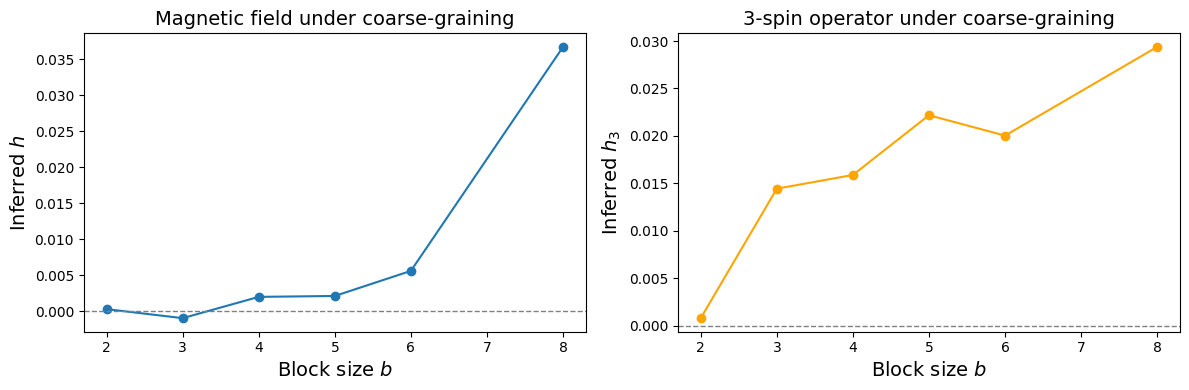

In [50]:
# Plot h and h3 under RG flow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot([item['b'] for item in h_RG], [item['h'] for item in h_RG], marker='o')
ax1.axhline(y=0, color='gray', linestyle='--', lw=1)
ax1.set_xlabel('Block size $b$', fontsize=14)
ax1.set_ylabel('Inferred $h$', fontsize=14)
ax1.set_title('Magnetic field under coarse-graining', fontsize=14)

ax2.plot([item['b'] for item in h3_RG], [item['h3'] for item in h3_RG], marker='o', color='orange')
ax2.axhline(y=0, color='gray', linestyle='--', lw=1)
ax2.set_xlabel('Block size $b$', fontsize=14)
ax2.set_ylabel('Inferred $h_3$', fontsize=14)
ax2.set_title('3-spin operator under coarse-graining', fontsize=14)

plt.tight_layout()
plt.show()


In [51]:
for k, h_item, h3_item in zip(K_RG, h_RG, h3_RG):
    print(f"b = {k['b']}: K = {k['K']}, h = {h_item['h']:.6f}, h3 = {h3_item['h3']:.6f}")

b = 2: K = [ 0.2842332   0.05174018  0.0012109  -0.00150299], h = 0.000306, h3 = 0.000798
b = 3: K = [ 0.35776463  0.04407664 -0.00797453 -0.00167253], h = -0.000947, h3 = 0.014442
b = 4: K = [ 0.37156826  0.04086534 -0.0106669  -0.00076072], h = 0.002012, h3 = 0.015888
b = 5: K = [ 0.3838329   0.03687287 -0.01604456  0.00252563], h = 0.002136, h3 = 0.022180
b = 6: K = [ 0.38462406  0.0356684  -0.01622383  0.00288109], h = 0.005620, h3 = 0.020036
b = 8: K = [ 0.37634626  0.03435387 -0.01119933 -0.00264614], h = 0.036744, h3 = 0.029384
